<a href="https://colab.research.google.com/github/ferraez062/CreandoUnaApi/blob/main/sesion_3_entrenamiento_ia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [ ]:
## Cargar el dataset y convertirlo en un dataframe de pandas
iris = load_iris(as_frame=True)
df = iris.frame

In [ ]:
print("\n Mostramos la cabecera del dataset")
print(df.head())

print("\n Mostramos la descripción del dataset")
print(df.describe())

print("\n Mostramos las clases de mi dataset")
print(df["target"].value_counts())


 Mostramos la cabecera del dataset
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

 Mostramos la descripción del dataset
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           

En la siguiente celda se va a realizar la divisiónd el dataset en dos
subconjuntos: entrenamiento y testing

In [ ]:
# Segmentación del dataset en Features (Características) - X
# y Labels (etiquetas) y
X = df.drop("target", axis = 1)
y = df["target"]

# Dividir nuestro dataset original en dos datasets
# Dataset de entrenamiento y dataset de testing
X_train, X_test, y_train, y_tests = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

print("Datos de entrenamiento: ", X_train.shape)
print("Datos de prueba: ", X_test.shape)


Datos de entrenamiento:  (120, 4)
Datos de prueba:  (30, 4)


Ejemplo de entrenamiento de un modelo de
clasificacaión multiclase

In [ ]:
# IMPORTS
"""

    Primero realizamos los imports

"""
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier # MultiLayerPerceptron
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import joblib # Exportar el modelo
import matplotlib.pyplot as plt # Módulo para graficar
import seaborn as sns


In [ ]:
### Cargar Dataset
data = load_iris()

# Obtener características y etiquetas de mi dataset
X = data.data
y = data.target

print("Clases", data.target_names) # Imprimirme los nombres de las clases
print("Características", data.feature_names) # Imprime los nombres de las características

# División de conjuntos, del conjunto original vamos a divir en training y testing
X_train, X_test, y_train, y_tests = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\n Dataset de Entrenamiento: ", X_train.shape)
print("\n Dataset de Prueba: ", X_test.shape)


# Escalador de datos
scaler = StandardScaler() # Normalizer

X_train = scaler.fit_transform(X_train) # Datos de entrenamiento escalados
X_test = scaler.fit_transform(X_test) # Datos de testing escalados

# Crear la red neuronal

model = MLPClassifier(
    hidden_layer_sizes=(8, 4),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

# Entrenar
model.fit(X_train, y_train)

print("\n Épocas ejectadoras: ", model.n_iter_)

Clases ['setosa' 'versicolor' 'virginica']
Características ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

 Dataset de Entrenamiento:  (120, 4)

 Dataset de Prueba:  (30, 4)

 Épocas ejectadoras:  1000


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


 
 TESTING - DATASET DE PRUEBAS
Exactitud:  0.9666666666666667

 Reporte de clasifación
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      1.00      0.95         9
   virginica       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



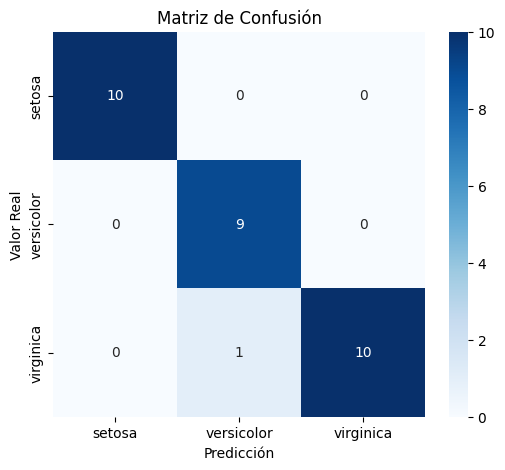


 Modelo exportado correctamente
Archivo generado: model_iris.pkl


In [ ]:

# Validar nuestro modelo - predicción de mi modelo utilizando el dataset de testing
y_pred = model.predict(X_test) # y_estimada
print(" \n TESTING - DATASET DE PRUEBAS")
print("Exactitud: ", accuracy_score(y_tests, y_pred))


# Reporte de clasificación
print("\n Reporte de clasifación")
print(
    classification_report(
        y_tests,
        y_pred,
        target_names=data.target_names
    )
)

# Matriz de confusión
cm = confusion_matrix(y_tests, y_pred)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt = "d",
    cmap="Blues",
    xticklabels=data.target_names,
    yticklabels=data.target_names,
)
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión")
plt.show()


# Exportar el mode
trained_model = {
    "model": model,
    "escalador": scaler,
    "feature_names": data.feature_names,  # Guardar las features de mi dataset
    "target_names": data.target_names      # Guardar las labels de mi dataset
}

joblib.dump(
    trained_model,
    "model_iris.pkl"
)

print("\n Modelo exportado correctamente")
print("Archivo generado: model_iris.pkl")


In [ ]:
import numpy as np
import joblib

# Importa modelo generado por el entrenamiento
data = joblib.load("model_iris.pkl")

# Obtener del diccionario el modelo, el scarler y las clases
model = data["model"]
scaler = data["escalador"]
clases = data["target_names"]

# Generar un dato de prueba

new_flower = np.array([
    5.1,
    3.5,
    1.4,
    0.2
]).reshape(1, -1)

# Con el dato de prueba lo escalamos
new_flower = scaler.transform(new_flower)

# El dato de prueba lo pasamos por el mode
pred = model.predict(new_flower)
prob = model.predict_proba(new_flower)

print("Clase: ", clases[pred[0]])

for i, name in enumerate(clases):
    print(f"{name}: {prob[0][i]}")

Clase:  setosa
setosa: 0.9988568653380058
versicolor: 0.0007537431449254017
virginica: 0.0003893915170687994
